# Civic Issue Detection using YOLO11 Classification

## Project Overview

This notebook builds a multi-class image classification model for identifying common civic issues from street-level images.

The final model classifies an input image into one of five categories:

- Garbage
- Open Manhole
- Pothole
- Road Normal
- Waterlogging

The goal is to build a lightweight computer vision model that can later be integrated into a civic issue reporting application.

### Model

We use **YOLO11n-cls**, the classification variant of YOLO11.

Rather than training a model from scratch, we start from pretrained weights and fine-tune them on our cleaned civic-issue dataset.

### High-level pipeline

Raw datasets
→ Dataset inspection
→ Image validation
→ Exact duplicate removal
→ Conflict handling
→ Train/validation/test split
→ Training-set balancing
→ YOLO11n-cls fine-tuning
→ Evaluation
→ Error analysis

> **Important:** This is an image classification problem, not object detection.  
> The model predicts the dominant class of the complete image rather than drawing bounding boxes around individual objects.# Civic Issue Detection using YOLO11 Classification

# Import Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Dataset Collection

Multiple publicly available datasets are combined to increase the diversity of the training data.

### Source datasets

We use four sources:

1. Civic Issue Reporting
2. Civic Issues Dataset
3. Roadway Flooding / Waterlogging Dataset
4. Pothole, Cracks and Open Manhole Dataset

We only retain classes relevant to the current problem.

### Selected classes

| Class | Description |
|---|---|
| `garbage` | Garbage / waste visible on roads or public areas |
| `pothole` | Potholes or damaged road surfaces |
| `open_manhole` | Open or uncovered manholes |
| `road_normal` | Normal road conditions |
| `waterlogging` | Water/flooding on roadways |

Streetlight-related classes are intentionally excluded from this version.

### Why merge multiple datasets?

A single dataset may have limited visual diversity or strong class imbalance.

Combining multiple sources provides:

- More visual variations
- Different camera viewpoints
- Different road environments
- Different lighting/weather conditions
- More examples of rare civic issues

However, merging datasets can introduce duplicate images and inconsistent labels. Therefore, dataset cleaning is performed before training.

In [3]:
import kagglehub

# Source 1: garbage, open manhole, potholes, road normal, streetlight bad & good
# Download latest version
path = kagglehub.dataset_download("harirajharsh/civic-issue-reporting")

print("Path to dataset files:", path)

# Source 2: Garbage, normal road, potholes, streetlights, waterlogging
# Download latest version
path = kagglehub.dataset_download("prince8tiwari/civic-issues-datasets")

print("Path to dataset files:", path)

# source 3: water logging/flooding - waterlogging
# Download latest version
path = kagglehub.dataset_download("saurabhshahane/roadway-flooding-image-dataset")

print("Path to dataset files:", path)


# Source 4: open manhole
# Download latest version
path = kagglehub.dataset_download("sabidrahman/pothole-cracks-and-openmanhole")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'civic-issue-reporting' dataset.
Path to dataset files: /kaggle/input/civic-issue-reporting


100%|██████████| 105M/105M [00:00<00:00, 115MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1


100%|██████████| 16.1M/16.1M [00:00<00:00, 44.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/saurabhshahane/roadway-flooding-image-dataset/versions/1


100%|██████████| 1.00G/1.00G [00:22<00:00, 48.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sabidrahman/pothole-cracks-and-openmanhole/versions/2


In [4]:
from pathlib import Path

sources = {
    "source1": Path("/kaggle/input/civic-issue-reporting"),
    "source2": Path("/root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1"),
    "source3": Path("/root/.cache/kagglehub/datasets/saurabhshahane/roadway-flooding-image-dataset/versions/1"),
    "source4": Path("/root/.cache/kagglehub/datasets/sabidrahman/pothole-cracks-and-openmanhole/versions/2"),
}

for name, path in sources.items():
    print(f"\n{'='*60}")
    print(name)
    print(path)

    for item in list(path.iterdir())[:30]:
        print(" ", item.name)


source1
/kaggle/input/civic-issue-reporting
  civic-issue-dataset

source2
/root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1
  Dataset

source3
/root/.cache/kagglehub/datasets/saurabhshahane/roadway-flooding-image-dataset/versions/1
  Dataset

source4
/root/.cache/kagglehub/datasets/sabidrahman/pothole-cracks-and-openmanhole/versions/2
  valid_annotations1.json
  potholedetectionpc.ipynb
  train_annotations1.json
  dataset


In [6]:
from pathlib import Path

for name, path in sources.items():
    print(f"\n{'='*70}")
    print(f"{name}: {path}")
    print("="*70)

    # Show directories that directly contain images
    for folder in sorted([p for p in path.rglob("*") if p.is_dir()]):
        count = sum(
            1 for f in folder.iterdir()
            if f.is_file() and f.suffix.lower() in IMAGE_EXTS
        )

        if count > 0:
            print(f"{count:5d} images  ->  {folder}")


source1: /kaggle/input/civic-issue-reporting
 2527 images  ->  /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/garbage
  152 images  ->  /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/open_manhole
 3508 images  ->  /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/potholes
  452 images  ->  /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/road_normal
   98 images  ->  /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/streetlight_bad
   55 images  ->  /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/streetlight_good

source2: /root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1
  453 images  ->  /root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1/Dataset/Garbage
  249 images  ->  /root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1/Dataset/plain
  250 images  ->  /root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-dat

In [7]:
from pathlib import Path

candidate_dirs = {
    "source1_garbage": Path(
        "/kaggle/input/civic-issue-reporting/civic-issue-dataset/images/garbage"
    ),
    "source1_manhole": Path(
        "/kaggle/input/civic-issue-reporting/civic-issue-dataset/images/open_manhole"
    ),
    "source1_pothole": Path(
        "/kaggle/input/civic-issue-reporting/civic-issue-dataset/images/potholes"
    ),
    "source1_road": Path(
        "/kaggle/input/civic-issue-reporting/civic-issue-dataset/images/road_normal"
    ),

    "source2_garbage": Path(
        "/root/.cache/kagglehub/datasets/prince8tiwari/"
        "civic-issues-datasets/versions/1/Dataset/Garbage"
    ),
    "source2_road": Path(
        "/root/.cache/kagglehub/datasets/prince8tiwari/"
        "civic-issues-datasets/versions/1/Dataset/plain"
    ),
    "source2_pothole": Path(
        "/root/.cache/kagglehub/datasets/prince8tiwari/"
        "civic-issues-datasets/versions/1/Dataset/potholes"
    ),
    "source2_water": Path(
        "/root/.cache/kagglehub/datasets/prince8tiwari/"
        "civic-issues-datasets/versions/1/Dataset/waterlogging"
    ),

    "source3_water": Path(
        "/root/.cache/kagglehub/datasets/saurabhshahane/"
        "roadway-flooding-image-dataset/versions/1/Dataset/images"
    ),

    "source4_road": Path(
        "/root/.cache/kagglehub/datasets/sabidrahman/"
        "pothole-cracks-and-openmanhole/versions/2/"
        "dataset/dataset/classes/good_road/images"
    ),
    "source4_manhole": Path(
        "/root/.cache/kagglehub/datasets/sabidrahman/"
        "pothole-cracks-and-openmanhole/versions/2/"
        "dataset/dataset/classes/open_manhole/images"
    ),
    "source4_pothole": Path(
        "/root/.cache/kagglehub/datasets/sabidrahman/"
        "pothole-cracks-and-openmanhole/versions/2/"
        "dataset/dataset/classes/pothole/images"
    ),
    "source4_pothole_valid": Path(
        "/root/.cache/kagglehub/datasets/sabidrahman/"
        "pothole-cracks-and-openmanhole/versions/2/"
        "dataset/dataset/classes/pothole/valid_pothole_images"
    ),
}

In [8]:
for name, path in candidate_dirs.items():
    files = [
        p for p in path.iterdir()
        if p.is_file()
    ]

    print(f"{name:25} {len(files):4}  {path}")

source1_garbage           2527  /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/garbage
source1_manhole            152  /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/open_manhole
source1_pothole           3508  /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/potholes
source1_road               452  /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/road_normal
source2_garbage            453  /root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1/Dataset/Garbage
source2_road               250  /root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1/Dataset/plain
source2_pothole            500  /root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1/Dataset/potholes
source2_water              441  /root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1/Dataset/waterlogging
source3_water              441  /root/.cache/kagglehub/datasets/sa

## 2. Image Validation

Before using any image for training, every file is checked to make sure it can be opened and decoded successfully.

Invalid or corrupted images can cause:

- Training crashes
- Incorrect dataset statistics
- Unexpected model behaviour

For each image we:

1. Open the image using PIL.
2. Verify that the image is readable.
3. Calculate a SHA-256 hash for duplicate detection.

The SHA-256 hash gives us a fingerprint of the image file, allowing exact duplicate files to be identified even when filenames are different.

In [9]:
import hashlib
from pathlib import Path
from PIL import Image
import pandas as pd
from tqdm.auto import tqdm

# ---------------------------------------------------------
# Candidate folders
# ---------------------------------------------------------

candidate_dirs = {
    "garbage": [
        Path("/kaggle/input/civic-issue-reporting/civic-issue-dataset/images/garbage"),
        Path("/root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1/Dataset/Garbage"),
    ],

    "pothole": [
        Path("/kaggle/input/civic-issue-reporting/civic-issue-dataset/images/potholes"),
        Path("/root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1/Dataset/potholes"),
        Path("/root/.cache/kagglehub/datasets/sabidrahman/pothole-cracks-and-openmanhole/versions/2/dataset/dataset/classes/pothole/images"),
        Path("/root/.cache/kagglehub/datasets/sabidrahman/pothole-cracks-and-openmanhole/versions/2/dataset/dataset/classes/pothole/valid_pothole_images"),
    ],

    "open_manhole": [
        Path("/kaggle/input/civic-issue-reporting/civic-issue-dataset/images/open_manhole"),
        Path("/root/.cache/kagglehub/datasets/sabidrahman/pothole-cracks-and-openmanhole/versions/2/dataset/dataset/classes/open_manhole/images"),
    ],

    "road_normal": [
        Path("/kaggle/input/civic-issue-reporting/civic-issue-dataset/images/road_normal"),
        Path("/root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1/Dataset/plain"),
        Path("/root/.cache/kagglehub/datasets/sabidrahman/pothole-cracks-and-openmanhole/versions/2/dataset/dataset/classes/good_road/images"),
    ],

    "waterlogging": [
        Path("/root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1/Dataset/waterlogging"),
        Path("/root/.cache/kagglehub/datasets/saurabhshahane/roadway-flooding-image-dataset/versions/1/Dataset/images"),
    ],
}

IMAGE_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp",
    ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"
}


def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        while chunk := f.read(chunk_size):
            h.update(chunk)

    return h.hexdigest()


# ---------------------------------------------------------
# Build manifest
# ---------------------------------------------------------

records = []

for class_name, folders in candidate_dirs.items():

    for folder in folders:

        files = [
            p for p in folder.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS
        ]

        for path in tqdm(
            files,
            desc=f"{class_name} | {folder.name}"
        ):
            try:
                # Verify image is readable
                with Image.open(path) as img:
                    img.verify()

                file_hash = sha256_file(path)

                records.append({
                    "class": class_name,
                    "path": str(path),
                    "filename": path.name,
                    "sha256": file_hash,
                })

            except Exception as e:
                records.append({
                    "class": class_name,
                    "path": str(path),
                    "filename": path.name,
                    "sha256": None,
                    "error": str(e),
                })


df = pd.DataFrame(records)

print("\nTotal files:", len(df))
print("Valid files:", df["sha256"].notna().sum())
print("Invalid files:", df["sha256"].isna().sum())

garbage | garbage:   0%|          | 0/2527 [00:00<?, ?it/s]

garbage | Garbage:   0%|          | 0/453 [00:00<?, ?it/s]

pothole | potholes:   0%|          | 0/3508 [00:00<?, ?it/s]

pothole | potholes:   0%|          | 0/250 [00:00<?, ?it/s]

pothole | images:   0%|          | 0/300 [00:00<?, ?it/s]

...

road_normal | plain:   0%|          | 0/249 [00:00<?, ?it/s]

road_normal | images:   0%|          | 0/100 [00:00<?, ?it/s]

waterlogging | waterlogging:   0%|          | 0/441 [00:00<?, ?it/s]

waterlogging | images:   0%|          | 0/441 [00:00<?, ?it/s]


Total files: 9125
Valid files: 9125
Invalid files: 0


## 3. Exact Duplicate Detection

Because the dataset comes from multiple sources, the same image can appear more than once.

For example:

```text
Source A
    image_123.jpg
          ↓
      same image
          ↑
Source B
    another_name.png

In [10]:
# Exact duplicate groups
duplicate_groups = (
    df[df["sha256"].notna()]
    .groupby("sha256")
    .filter(lambda x: len(x) > 1)
    .sort_values("sha256")
)

print("Exact duplicate files:", len(duplicate_groups))

print("\nNumber of duplicate groups:",
      duplicate_groups["sha256"].nunique())

# Show duplicate groups
for h, group in duplicate_groups.groupby("sha256"):
    print("\n" + "=" * 100)

    for _, row in group.iterrows():
        print(
            f"{row['class']:15} | "
            f"{row['filename']:45} | "
            f"{row['path']}"
        )

Exact duplicate files: 2986

Number of duplicate groups: 1255

waterlogging    | image_289.jpg                                 | /root/.cache/kagglehub/datasets/saurabhshahane/roadway-flooding-image-dataset/versions/1/Dataset/images/image_289.jpg
waterlogging    | image_289.jpg                                 | /root/.cache/kagglehub/datasets/prince8tiwari/civic-issues-datasets/versions/1/Dataset/waterlogging/image_289.jpg

pothole         | 1048.jpg                                      | /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/potholes/1048.jpg
open_manhole    | 1048.jpg                                      | /kaggle/input/civic-issue-reporting/civic-issue-dataset/images/open_manhole/1048.jpg
open_manhole    | 1048.jpg                                      | /root/.cache/kagglehub/datasets/sabidrahman/pothole-cracks-and-openmanhole/versions/2/dataset/dataset/classes/open_manhole/images/1048.jpg

pothole         | 160.jpg                                       | /r

In [11]:
import os
import shutil
from pathlib import Path
from collections import defaultdict

import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm


# ============================================================
# CONFIG
# ============================================================

WORK_DIR = Path("/content/civic_dataset_work")
REVIEW_DIR = WORK_DIR / "conflict_review"

WORK_DIR.mkdir(parents=True, exist_ok=True)
REVIEW_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. REMOVE INVALID FILES
# ============================================================

df_valid = df[df["sha256"].notna()].copy()

print("Valid images:", len(df_valid))


# ============================================================
# 2. FIND EXACT DUPLICATE GROUPS
# ============================================================

groups = (
    df_valid
    .groupby("sha256")
    .agg(
        paths=("path", list),
        classes=("class", lambda x: sorted(set(x))),
        count=("path", "count"),
    )
    .reset_index()
)

print("Unique SHA groups:", len(groups))
print("Duplicate groups:", (groups["count"] > 1).sum())


# ============================================================
# 3. FIND CROSS-CLASS CONFLICTS
# ============================================================

conflicts = groups[
    groups["classes"].apply(len) > 1
].copy()

print("\nCross-class conflict groups:", len(conflicts))

print("\nConflict types:")

conflict_types = (
    conflicts["classes"]
    .apply(lambda x: " + ".join(x))
    .value_counts()
)

print(conflict_types)


# ============================================================
# 4. CREATE REVIEW CSV
# ============================================================

review_rows = []

for idx, row in conflicts.iterrows():

    conflict_id = f"conflict_{len(review_rows):04d}"

    review_rows.append({
        "conflict_id": conflict_id,
        "sha256": row["sha256"],
        "classes": " + ".join(row["classes"]),
        "num_files": row["count"],
        "decision": "",      # YOU fill this
        "notes": "",
        "paths": " || ".join(row["paths"]),
    })


review_df = pd.DataFrame(review_rows)

review_csv = WORK_DIR / "conflict_review.csv"
review_df.to_csv(review_csv, index=False)

print("\nReview CSV:")
print(review_csv)


# ============================================================
# 5. CREATE CONTACT SHEETS
# ============================================================

def make_contact_sheet(
    image_paths,
    labels,
    conflict_id,
    output_path,
    thumb_size=(300, 220),
    cols=3
):

    rows = (len(image_paths) + cols - 1) // cols

    cell_w = thumb_size[0]
    cell_h = thumb_size[1] + 55

    sheet = Image.new(
        "RGB",
        (cols * cell_w, rows * cell_h),
        "white"
    )

    draw = ImageDraw.Draw(sheet)

    for i, (path, label) in enumerate(
        zip(image_paths, labels)
    ):

        x = (i % cols) * cell_w
        y = (i // cols) * cell_h

        try:
            img = Image.open(path).convert("RGB")
            img.thumbnail(thumb_size)

            px = x + (cell_w - img.width) // 2
            py = y + 5

            sheet.paste(img, (px, py))

            draw.text(
                (x + 5, y + thumb_size[1] + 5),
                f"{label}\n{Path(path).name}",
                fill="black"
            )

        except Exception as e:

            draw.text(
                (x + 5, y + 10),
                f"ERROR\n{Path(path).name}",
                fill="red"
            )

    sheet.save(output_path)


# Create ONE sheet per conflict group

for _, row in tqdm(
    conflicts.iterrows(),
    total=len(conflicts),
    desc="Creating conflict sheets"
):

    conflict_id = f"conflict_{list(conflicts.index).index(row.name):04d}"

    paths = row["paths"]
    classes = row["classes"]

    labels = []

    for path in paths:

        # Find label of this exact path
        matches = df_valid[df_valid["path"] == path]

        if len(matches):
            labels.append(matches.iloc[0]["class"])
        else:
            labels.append("unknown")

    output = REVIEW_DIR / f"{conflict_id}.jpg"

    make_contact_sheet(
        paths,
        labels,
        conflict_id,
        output
    )


print(
    f"\nCreated {len(conflicts)} conflict sheets in:"
    f"\n{REVIEW_DIR}"
)

Valid images: 9125
Unique SHA groups: 7394
Duplicate groups: 1255

Cross-class conflict groups: 233

Conflict types:
classes
open_manhole + pothole    133
pothole + road_normal     100
Name: count, dtype: int64

Review CSV:
/content/civic_dataset_work/conflict_review.csv


Creating conflict sheets:   0%|          | 0/233 [00:00<?, ?it/s]


Created 233 conflict sheets in:
/content/civic_dataset_work/conflict_review


In [12]:
import os

print("Review directory:")
print(REVIEW_DIR)

print("\nFiles:")
for p in sorted(REVIEW_DIR.iterdir())[:20]:
    print(p.name)

Review directory:
/content/civic_dataset_work/conflict_review

Files:
conflict_0000.jpg
conflict_0001.jpg
conflict_0002.jpg
conflict_0003.jpg
conflict_0004.jpg
conflict_0005.jpg
conflict_0006.jpg
conflict_0007.jpg
conflict_0008.jpg
conflict_0009.jpg
conflict_0010.jpg
conflict_0011.jpg
conflict_0012.jpg
conflict_0013.jpg
conflict_0014.jpg
conflict_0015.jpg
conflict_0016.jpg
conflict_0017.jpg
conflict_0018.jpg
conflict_0019.jpg


In [13]:
from PIL import Image, ImageDraw
from pathlib import Path
import math

REVIEW_DIR = Path("/content/civic_dataset_work/conflict_review")
OUTPUT = Path("/content/conflict_overview.jpg")

files = sorted(REVIEW_DIR.glob("*.jpg"))

# thumbnails
W, H = 320, 260
COLS = 4
ROWS_PER_SHEET = 5

sheets = []

for start in range(0, len(files), COLS * ROWS_PER_SHEET):

    batch = files[start:start + COLS * ROWS_PER_SHEET]

    sheet = Image.new(
        "RGB",
        (COLS * W, ROWS_PER_SHEET * H),
        "white"
    )

    draw = ImageDraw.Draw(sheet)

    for i, file in enumerate(batch):

        try:
            img = Image.open(file).convert("RGB")
            img.thumbnail((W - 10, H - 45))

            x = (i % COLS) * W
            y = (i // COLS) * H

            px = x + (W - img.width) // 2
            py = y + 5

            sheet.paste(img, (px, py))

            draw.text(
                (x + 8, y + H - 35),
                file.stem,
                fill="black"
            )

        except Exception as e:
            print("Error:", file, e)

    sheets.append(sheet)


# Combine all sheets vertically
final = Image.new(
    "RGB",
    (
        COLS * W,
        len(sheets) * ROWS_PER_SHEET * H
    ),
    "white"
)

for i, sheet in enumerate(sheets):
    final.paste(
        sheet,
        (0, i * ROWS_PER_SHEET * H)
    )

final.save(OUTPUT, quality=90)

print(f"Created: {OUTPUT}")
print(f"Conflict images: {len(files)}")

Created: /content/conflict_overview.jpg
Conflict images: 233


In [14]:
from pathlib import Path
import hashlib
import shutil
import random
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image

# ============================================================
# CONFIG
# ============================================================

SEED = 42

OUTPUT = Path("/content/civic_dataset")

# Remove old dataset if it exists
if OUTPUT.exists():
    shutil.rmtree(OUTPUT)

for split in ["train", "val", "test"]:
    for cls in [
        "garbage",
        "pothole",
        "open_manhole",
        "road_normal",
        "waterlogging",
    ]:
        (OUTPUT / split / cls).mkdir(
            parents=True,
            exist_ok=True
        )

# ============================================================
# SOURCE DIRECTORIES
# ============================================================

sources = {
    "garbage": [
        Path(
            "/kaggle/input/civic-issue-reporting/"
            "civic-issue-dataset/images/garbage"
        ),
        Path(
            "/root/.cache/kagglehub/datasets/prince8tiwari/"
            "civic-issues-datasets/versions/1/Dataset/Garbage"
        ),
    ],

    "pothole": [
        Path(
            "/kaggle/input/civic-issue-reporting/"
            "civic-issue-dataset/images/potholes"
        ),
        Path(
            "/root/.cache/kagglehub/datasets/prince8tiwari/"
            "civic-issues-datasets/versions/1/Dataset/potholes"
        ),
        Path(
            "/root/.cache/kagglehub/datasets/sabidrahman/"
            "pothole-cracks-and-openmanhole/versions/2/"
            "dataset/dataset/classes/pothole/images"
        ),
        Path(
            "/root/.cache/kagglehub/datasets/sabidrahman/"
            "pothole-cracks-and-openmanhole/versions/2/"
            "dataset/dataset/classes/pothole/valid_pothole_images"
        ),
    ],

    "open_manhole": [
        Path(
            "/kaggle/input/civic-issue-reporting/"
            "civic-issue-dataset/images/open_manhole"
        ),
        Path(
            "/root/.cache/kagglehub/datasets/sabidrahman/"
            "pothole-cracks-and-openmanhole/versions/2/"
            "dataset/dataset/classes/open_manhole/images"
        ),
    ],

    "road_normal": [
        Path(
            "/kaggle/input/civic-issue-reporting/"
            "civic-issue-dataset/images/road_normal"
        ),
        Path(
            "/root/.cache/kagglehub/datasets/prince8tiwari/"
            "civic-issues-datasets/versions/1/Dataset/plain"
        ),
        Path(
            "/root/.cache/kagglehub/datasets/sabidrahman/"
            "pothole-cracks-and-openmanhole/versions/2/"
            "dataset/dataset/classes/good_road/images"
        ),
    ],

    "waterlogging": [
        Path(
            "/root/.cache/kagglehub/datasets/prince8tiwari/"
            "civic-issues-datasets/versions/1/Dataset/waterlogging"
        ),
        Path(
            "/root/.cache/kagglehub/datasets/saurabhshahane/"
            "roadway-flooding-image-dataset/versions/1/"
            "Dataset/images"
        ),
    ],
}

IMAGE_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}


# ============================================================
# HASH FUNCTION
# ============================================================

def sha256_file(path, chunk_size=1024 * 1024):

    h = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ============================================================
# COLLECT ALL IMAGES
# ============================================================

records = []

print("Collecting images...\n")

for class_name, folders in sources.items():

    for folder in folders:

        files = [
            p for p in folder.iterdir()
            if (
                p.is_file()
                and p.suffix.lower() in IMAGE_EXTS
            )
        ]

        print(
            f"{class_name:15} "
            f"{folder.name:30} "
            f"{len(files):5}"
        )

        for path in tqdm(
            files,
            desc=f"{class_name}/{folder.name}",
            leave=False
        ):

            try:

                # Check image integrity
                with Image.open(path) as img:
                    img.verify()

                file_hash = sha256_file(path)

                records.append({
                    "class": class_name,
                    "path": str(path),
                    "filename": path.name,
                    "sha256": file_hash,
                })

            except Exception as e:

                print(
                    f"\nSkipping bad image: {path}"
                )
                print(e)


df = pd.DataFrame(records)

print("\n====================================")
print("RAW DATA")
print("====================================")
print("Images:", len(df))


# ============================================================
# CONFLICT RESOLUTION
# ============================================================

# Higher priority wins when identical image appears
# with multiple labels.

PRIORITY = {
    "open_manhole": 5,
    "pothole": 4,
    "waterlogging": 3,
    "garbage": 2,
    "road_normal": 1,
}


# Group identical files
groups = (
    df
    .groupby("sha256")
    .agg(
        paths=("path", list),
        classes=("class", lambda x: sorted(set(x))),
        count=("path", "count"),
    )
    .reset_index()
)


# ============================================================
# BUILD ONE RECORD PER UNIQUE IMAGE
# ============================================================

clean_records = []

conflict_count = 0
duplicate_count = 0

for _, row in groups.iterrows():

    classes = row["classes"]

    # Duplicate image
    if row["count"] > 1:
        duplicate_count += row["count"] - 1

    # Conflict
    if len(classes) > 1:

        conflict_count += 1

        # Highest-priority class wins
        final_class = max(
            classes,
            key=lambda x: PRIORITY[x]
        )

    else:

        final_class = classes[0]

    # Pick first physical file
    source_path = row["paths"][0]

    clean_records.append({
        "sha256": row["sha256"],
        "path": source_path,
        "final_class": final_class,
        "original_classes": "|".join(classes),
    })


clean_df = pd.DataFrame(clean_records)


# ============================================================
# FINAL UNIQUE DATASET
# ============================================================

print("\n====================================")
print("DEDUPLICATION")
print("====================================")

print("Original images :", len(df))
print("Unique images   :", len(clean_df))
print("Duplicates removed:", duplicate_count)
print("Conflict groups :", conflict_count)


print("\n====================================")
print("FINAL CLASS COUNTS")
print("====================================")

print(
    clean_df["final_class"]
    .value_counts()
    .sort_index()
)


# ============================================================
# SPLIT BY CLASS
# ============================================================

random.seed(SEED)

train_records = []
val_records = []
test_records = []

for class_name, group in clean_df.groupby(
    "final_class"
):

    group = group.sample(
        frac=1,
        random_state=SEED
    ).reset_index(drop=True)

    n = len(group)

    # 70 / 15 / 15
    n_train = int(n * 0.70)
    n_val = int(n * 0.15)

    train = group.iloc[:n_train]

    val = group.iloc[
        n_train:n_train + n_val
    ]

    test = group.iloc[
        n_train + n_val:
    ]

    train_records.append(train)
    val_records.append(val)
    test_records.append(test)


train_df = pd.concat(
    train_records,
    ignore_index=True
)

val_df = pd.concat(
    val_records,
    ignore_index=True
)

test_df = pd.concat(
    test_records,
    ignore_index=True
)


# ============================================================
# COPY FILES
# ============================================================

def copy_dataset(df_split, split_name):

    print(
        f"\nCopying {split_name}..."
    )

    for _, row in tqdm(
        df_split.iterrows(),
        total=len(df_split),
    ):

        source = Path(row["path"])

        cls = row["final_class"]

        # Hash prefix prevents filename collisions
        filename = (
            f"{row['sha256'][:12]}_"
            f"{source.name}"
        )

        destination = (
            OUTPUT /
            split_name /
            cls /
            filename
        )

        shutil.copy2(
            source,
            destination
        )


copy_dataset(
    train_df,
    "train"
)

copy_dataset(
    val_df,
    "val"
)

copy_dataset(
    test_df,
    "test"
)


# ============================================================
# SAVE MANIFESTS
# ============================================================

clean_df.to_csv(
    OUTPUT / "clean_manifest.csv",
    index=False
)

train_df.to_csv(
    OUTPUT / "train_manifest.csv",
    index=False
)

val_df.to_csv(
    OUTPUT / "val_manifest.csv",
    index=False
)

test_df.to_csv(
    OUTPUT / "test_manifest.csv",
    index=False
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("CIVIC DATASET CREATED")
print("=" * 60)

print(f"Location: {OUTPUT}")

print("\nTRAIN")
print(
    train_df["final_class"]
    .value_counts()
    .sort_index()
)

print("\nVAL")
print(
    val_df["final_class"]
    .value_counts()
    .sort_index()
)

print("\nTEST")
print(
    test_df["final_class"]
    .value_counts()
    .sort_index()
)

print("\nTOTAL")
print(
    len(train_df),
    "+",
    len(val_df),
    "+",
    len(test_df),
    "=",
    len(clean_df)
)


garbage         garbage                         2527


garbage/garbage:   0%|          | 0/2527 [00:00<?, ?it/s]

garbage         Garbage                          453


garbage/Garbage:   0%|          | 0/453 [00:00<?, ?it/s]

pothole         potholes                        3508


...


Copying val...


  0%|          | 0/1107 [00:00<?, ?it/s]


Copying test...


  0%|          | 0/1113 [00:00<?, ?it/s]



CIVIC DATASET CREATED
Location: /content/civic_dataset

TRAIN
final_class
garbage         2076
open_manhole      97
pothole         2445
road_normal      248
waterlogging     308
Name: count, dtype: int64

VAL
final_class
garbage         444
open_manhole     20
pothole         524
road_normal      53
waterlogging     66
Name: count, dtype: int64

TEST
final_class
garbage         446
open_manhole     22
pothole         525
road_normal      54
waterlogging     66
Name: count, dtype: int64

TOTAL
5174 + 1107 + 1113 = 7394


## Dataset Cleaning Results

After combining all four sources, we obtained:

- **9,125 valid image files**
- **7,394 unique images**
- **1,731 exact duplicate files removed**
- **233 duplicate groups contained conflicting class labels**

This demonstrates why dataset cleaning was necessary before model training.

Some images appeared under different labels, particularly between:

- `pothole`
- `open_manhole`
- `road_normal`

For this baseline experiment, conflicting labels were resolved using a deterministic class-priority rule so that every unique image has exactly one final class.

The resulting clean dataset contains:

| Class | Unique Images |
|---|---:|
| Garbage | 2,966 |
| Pothole | 3,494 |
| Open Manhole | 139 |
| Road Normal | 355 |
| Waterlogging | 440 |
| **Total** | **7,394** |


# 4. Handling Class Imbalance

The cleaned dataset is still highly imbalanced.

Before balancing:

| Class | Training Images |
|---|---:|
| Garbage | 2,076 |
| Pothole | 2,445 |
| Open Manhole | 97 |
| Road Normal | 248 |
| Waterlogging | 308 |

The largest class has substantially more images than the smallest class.

If we train directly on this distribution, the model may become biased toward the dominant classes.

### Baseline strategy

For the first experiment, we intentionally reduce the two largest classes to approximately 400 images:

| Class | Training Images |
|---|---:|
| Garbage | 400 |
| Pothole | 400 |
| Open Manhole | 97 |
| Road Normal | 248 |
| Waterlogging | 308 |
| **Total** | **1,453** |

We do **not** modify the validation or test sets.

This gives us a controlled baseline while preserving the original validation/test distributions for realistic evaluation.

> The open-manhole class is intentionally kept at all available images because it is the rarest class.

In [16]:
from pathlib import Path
import random
import shutil

DATASET = Path("/content/civic_dataset")
BALANCED = Path("/content/civic_dataset_balanced")

print("\nBalanced training dataset:")

if BALANCED.exists():
    shutil.rmtree(BALANCED)

classes = [
    "garbage",
    "pothole",
    "open_manhole",
    "road_normal",
    "waterlogging",
]

TARGETS = {
    "garbage": 400,
    "pothole": 400,
    "open_manhole": 97,
    "road_normal": 248,
    "waterlogging": 308,
}

random.seed(42)

for cls in classes:

    source_dir = DATASET / "train" / cls
    target_dir = BALANCED / "train" / cls

    target_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    images = [
        p for p in source_dir.iterdir()
        if p.is_file()
    ]

    target = min(
        TARGETS[cls],
        len(images)
    )

    selected = random.sample(
        images,
        target
    )

    for image in selected:
        shutil.copy2(
            image,
            target_dir / image.name
        )

    print(
        f"{cls:15} "
        f"{len(images):4} → {len(selected):4}"
    )


Balanced training dataset:
garbage         2076 →  400
pothole         2445 →  400
open_manhole      97 →   97
road_normal      248 →  248
waterlogging     308 →  308


In [17]:
!pip -q install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.3 MB/s eta 0:00:00


In [28]:
import shutil
from pathlib import Path

SOURCE = Path("/content/civic_dataset")
BALANCED = Path("/content/civic_dataset_balanced")

# Remove old val/test if they somehow exist
for split in ["val", "test"]:
    dst = BALANCED / split

    if dst.exists():
        shutil.rmtree(dst)

    shutil.copytree(
        SOURCE / split,
        dst
    )

print("Dataset structure:")
for split in ["train", "val", "test"]:
    print(
        split,
        "->",
        sum(
            1 for p in (BALANCED / split).rglob("*")
            if p.is_file()
        ),
        "images"
    )

Dataset structure:
train -> 1453 images
val -> 1107 images
test -> 1113 images


In [29]:
from pathlib import Path

for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")

    for cls in [
        "garbage",
        "pothole",
        "open_manhole",
        "road_normal",
        "waterlogging",
    ]:

        path = Path("/content/civic_dataset_balanced") / split / cls

        print(
            f"{cls:15} {len(list(path.glob('*'))):4}"
        )


TRAIN
garbage          400
pothole          400
open_manhole      97
road_normal      248
waterlogging     308

VAL
garbage          444
pothole          524
open_manhole      20
road_normal       53
waterlogging      66

TEST
garbage          446
pothole          525
open_manhole      22
road_normal       54
waterlogging      66


## Validation and Test Sets

The validation and test sets are kept untouched.

This is important because artificially balancing the evaluation data can make the reported performance less representative of real-world usage.

Final split:

- **Training:** 1,453 images
- **Validation:** 1,107 images
- **Test:** 1,113 images

The training set is controlled for class imbalance, while validation and test retain the original class distribution.

# 5. YOLO11n-cls Fine-Tuning

We use **YOLO11n-cls**, the classification version of YOLO11.

### Why YOLO11n-cls?

The `n` (nano) model is lightweight and suitable for applications where inference speed and deployment size matter.

Instead of training from random initialization, we load the pretrained `yolo11n-cls.pt` weights and fine-tune them on our five civic-issue classes.

### Training configuration

| Parameter | Value |
|---|---:|
| Model | YOLO11n-cls |
| Task | Image Classification |
| Classes | 5 |
| Image size | 224 × 224 |
| Epochs | 10 |
| Batch size | 16 |
| Optimizer | Auto / AdamW |
| Seed | 42 |

### Training objective

The model learns visual features that distinguish:

`garbage` vs `pothole` vs `open_manhole` vs `road_normal` vs `waterlogging`.

Because this is classification, the model outputs class probabilities rather than bounding boxes.

In [39]:
from ultralytics import YOLO

model = YOLO("yolo11n-cls.pt")

results = model.train(
    data="/content/civic_dataset_balanced",

    epochs=10,
    imgsz=224,
    batch=16,

    device="cpu",
    workers=2,

    patience=10,
    seed=42,

    project="/content/civic_training",
    name="civic_yolo11n_v1",
)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/civic_dataset_balanced, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=civic_yolo11n_v1-2, nb

# 6. Model Evaluation

Training accuracy alone is not sufficient to determine whether the model generalizes.

Therefore, the trained model is evaluated on the held-out test set.

We use:

### Top-1 Accuracy

The percentage of images where the model's highest-probability prediction is the correct class.

### Top-5 Accuracy

Whether the correct class appears anywhere in the model's five highest-probability predictions.

Because we only have five classes, Top-5 accuracy is expected to be very high and is less informative than Top-1 accuracy.

For this project, **Top-1 accuracy and per-class performance are the important metrics**.

In [40]:
from ultralytics import YOLO

model = YOLO(
    "/content/civic_training/"
    "civic_yolo11n_v1-2/weights/best.pt"
)

In [41]:
metrics = model.val(
    data="/content/civic_dataset_balanced",
    split="test",
    imgsz=224,
    batch=16,
    device="cpu",
)

print(metrics)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n-cls summary (fused): 47 layers, 1,532,429 parameters, 0 gradients, 3.2 GFLOPs
train: /content/civic_dataset_balanced/train... found 1453 images in 5 classes ✅ 
val: /content/civic_dataset_balanced/val... found 1107 images in 5 classes ✅ 
test: /content/civic_dataset_balanced/test... found 1113 images in 5 classes ✅ 
WARNING ⚠️ test: Slow image access detected (ping: 0.1±0.0 ms, read: 2.8±1.5 MB/s, size: 16.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
test: Scanning /content/civic_dataset_balanced/test... 1112 images, 1 corrupt: 100% ━━━━━━━━━━━━ 1113/1113 669.2it/s 1.7s
test: /content/civic_dataset_balanced/test/road_normal/709c7f8f6185_226.jpg: ignoring corrupt image/label: Invalid image format GIF. Supported formats are:
images: {'mpo', 'webp', 'jp2', 'png', 'dng', 'bmp', 'avif', 'tiff', 'heic',

In [42]:
print(metrics.results_dict)

{'metrics/accuracy_top1': 0.9127697944641113, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9563848972320557}


## Baseline Results

The first YOLO11n-cls model achieved:

- **Validation Top-1 Accuracy: 92.6%**
- **Test Top-1 Accuracy: 91.28%**
- **Test Top-5 Accuracy: 100%**

The validation and test results are relatively close, which indicates that the model generalizes reasonably well to the held-out test data.

However, overall accuracy does not tell us how well each civic issue is recognized.

Therefore, we analyze the confusion matrix next.

## 7. Error Analysis — Confusion Matrix

A confusion matrix shows which classes the model confuses with one another.

This is particularly important for this problem because some civic issues have visually similar characteristics.

For example:

- A pothole and an open manhole can both appear as dark openings/damaged areas on a road.
- Waterlogging can partially hide road damage.
- A normal road can contain small visual irregularities.

The normalized confusion matrix allows us to compare class-wise recall despite the unequal number of samples in the test set.

confusion_matrix_normalized.png


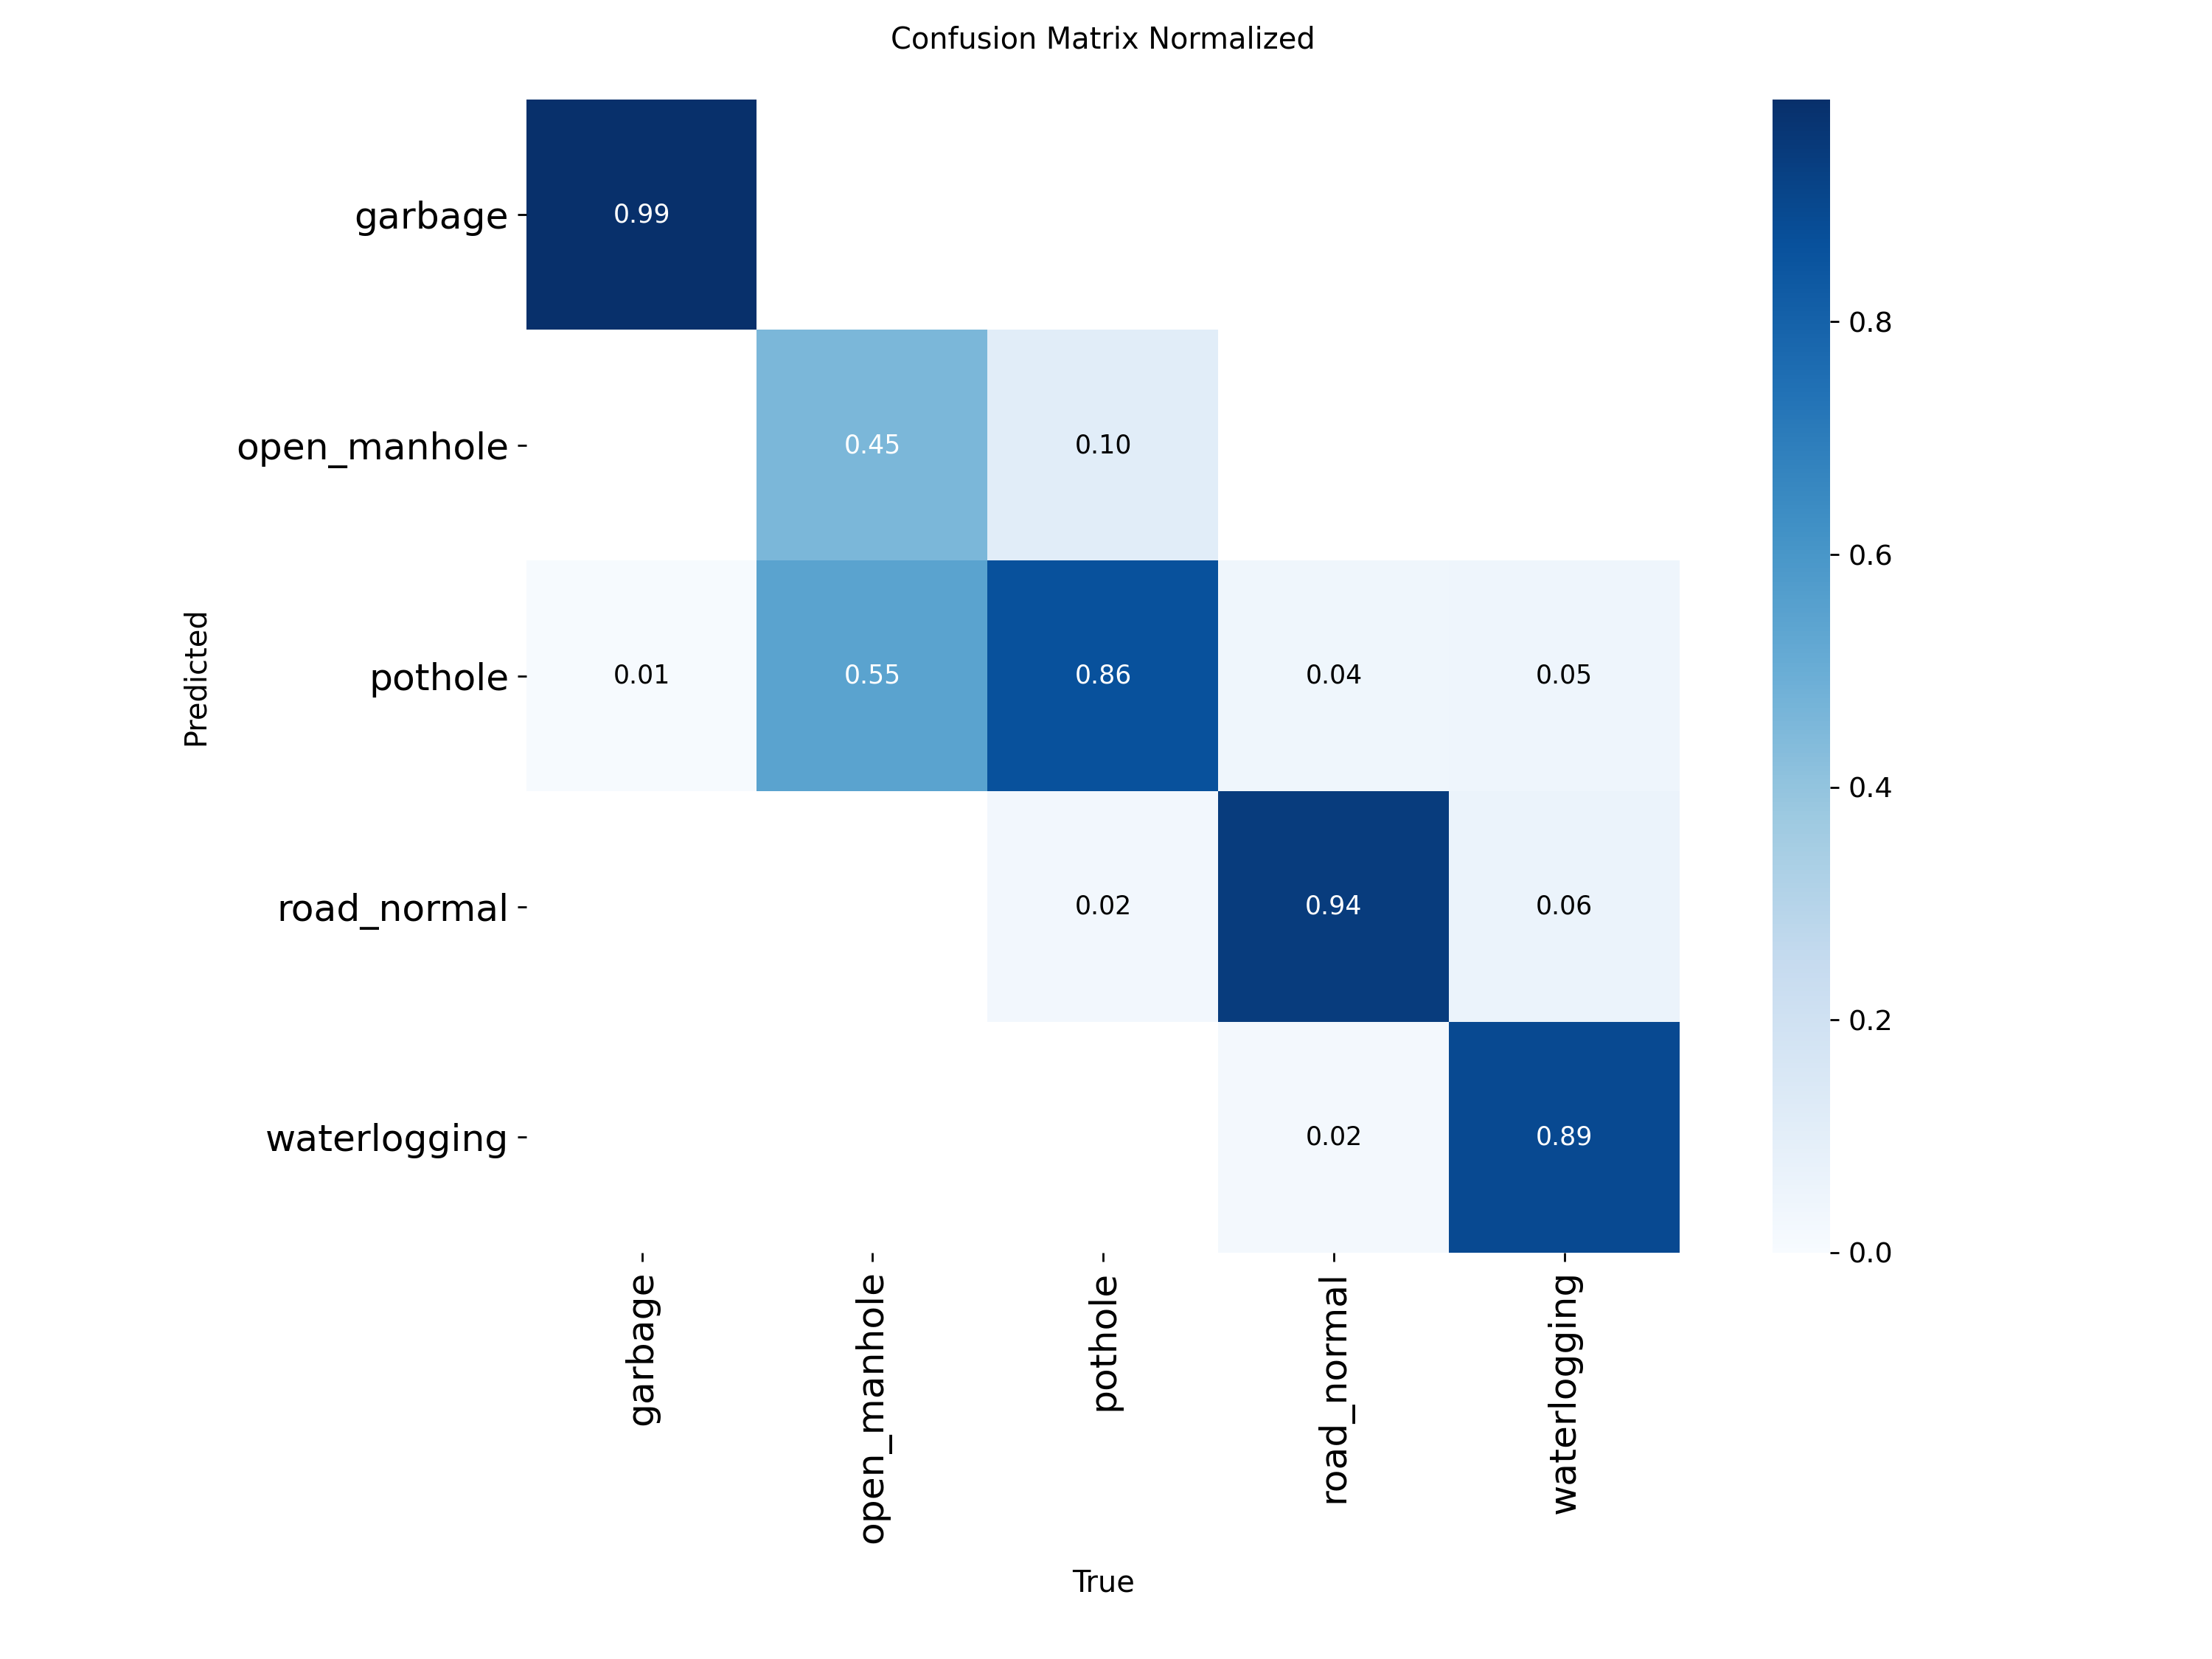

In [44]:
from pathlib import Path
from IPython.display import display
from PIL import Image

run_dir = Path("/content/runs/classify/val")

for name in [
    "confusion_matrix_normalized.png",
]:
    path = run_dir / name

    if path.exists():
        print(name)
        display(Image.open(path))

## Confusion Matrix Analysis

The baseline model performs strongly on most classes:

- **Garbage:** ~99% recall
- **Pothole:** ~86% recall
- **Road Normal:** ~94% recall
- **Waterlogging:** ~89% recall

The main weakness is **Open Manhole**, with approximately **45% recall**.

The dominant error is:

```text
Open Manhole → Pothole


Reason: Open Manhole has very less image inputs

# Downloading Best Model

In [45]:
from google.colab import files

best_model = (
    "/content/civic_training/"
    "civic_yolo11n_v1-2/weights/best.pt"
)

files.download(best_model)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Class Mapping

In [46]:
classes = [
    "garbage",
    "open_manhole",
    "pothole",
    "road_normal",
    "waterlogging",
]

print({
    i: name
    for i, name in enumerate(classes)
})

{0: 'garbage', 1: 'open_manhole', 2: 'pothole', 3: 'road_normal', 4: 'waterlogging'}


In [47]:
import json

class_map = {
    0: "garbage",
    1: "open_manhole",
    2: "pothole",
    3: "road_normal",
    4: "waterlogging",
}

with open("/content/classes.json", "w") as f:
    json.dump(class_map, f, indent=2)

from google.colab import files
files.download("/content/classes.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>